In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load Iris Dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0:'setosa',1:'versicolor',2:'virginica'})

print("✅ Dataset Loaded!")
print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['species'].value_counts())
df.head()

✅ Dataset Loaded!
Shape: (150, 6)

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [2]:
X = df[iris.feature_names]
y = df['target']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Feature Scaling Done!")
print("Before scaling - Mean:", round(X.mean().mean(), 2))
print("After  scaling - Mean:", round(X_scaled.mean(), 2))
print("After  scaling - Std :", round(X_scaled.std(), 2))

✅ Feature Scaling Done!
Before scaling - Mean: 3.46
After  scaling - Mean: -0.0
After  scaling - Std : 1.0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("✅ Train-Test Split Done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

✅ Train-Test Split Done!
Training samples : 120
Testing  samples : 30


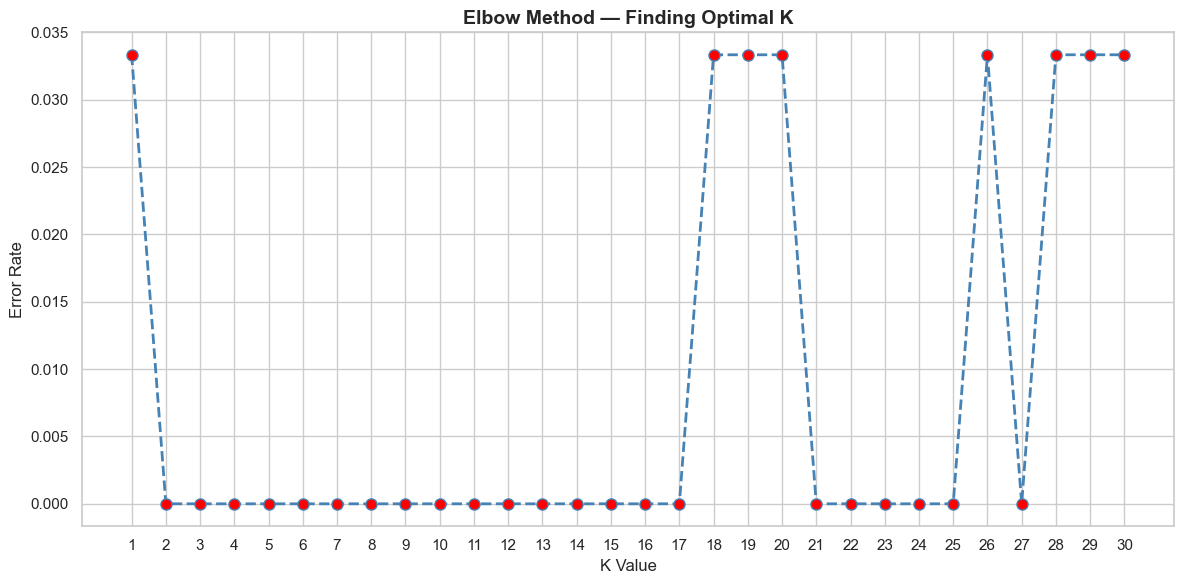

✅ Optimal K = 2


In [4]:
error_rates = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, pred))

# Plot Elbow Curve
plt.figure(figsize=(12, 6))
plt.plot(k_range, error_rates, color='steelblue',
         linestyle='--', marker='o', markerfacecolor='red',
         markersize=8, linewidth=2)
plt.title('Elbow Method — Finding Optimal K',
          fontsize=14, fontweight='bold')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmin(error_rates)]
print(f"✅ Optimal K = {optimal_k}")

In [5]:
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train, y_train)

print(f"✅ KNN Model Trained with K = {optimal_k}")

✅ KNN Model Trained with K = 2


      KNN MODEL EVALUATION
✅ Accuracy  : 100.00%
✅ F1 Score  : 1.0000
✅ Optimal K : 2

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



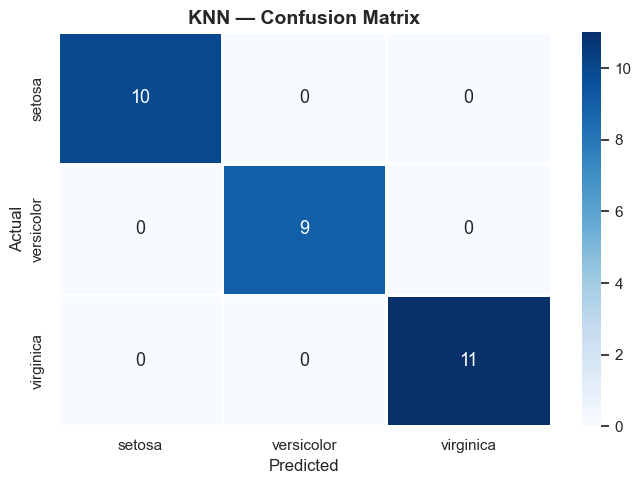

In [6]:
y_pred = knn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("=" * 45)
print("      KNN MODEL EVALUATION")
print("=" * 45)
print(f"✅ Accuracy  : {accuracy*100:.2f}%")
print(f"✅ F1 Score  : {f1:.4f}")
print(f"✅ Optimal K : {optimal_k}")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['setosa','versicolor','virginica']))

# Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa','versicolor','virginica'],
            yticklabels=['setosa','versicolor','virginica'],
            linewidths=1, annot_kws={'size':13})
plt.title('KNN — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

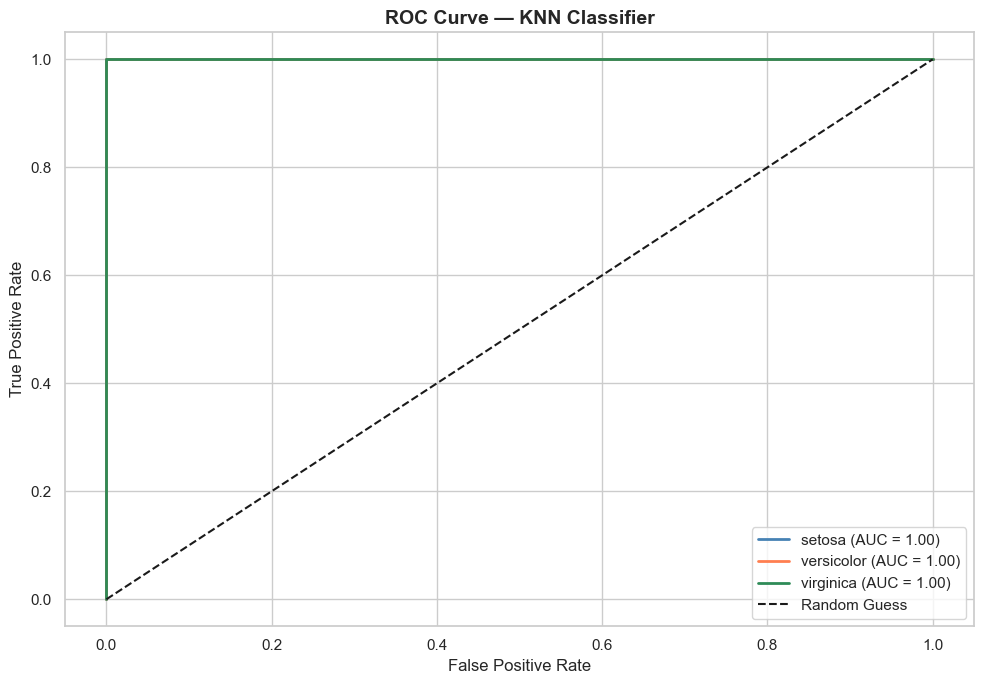

✅ ROC Curve plotted!


In [7]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Binarize for multiclass ROC
y_bin = label_binarize(y, classes=[0, 1, 2])
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_bin, test_size=0.2, random_state=42)

knn_ovr = OneVsRestClassifier(
    KNeighborsClassifier(n_neighbors=optimal_k))
knn_ovr.fit(X_train_r, y_train_r)
y_score = knn_ovr.predict_proba(X_test_r)

# Plot ROC for each class
plt.figure(figsize=(10, 7))
colors = ['steelblue', 'coral', 'seagreen']
classes = ['setosa', 'versicolor', 'virginica']

for i, (color, cls) in enumerate(zip(colors, classes)):
    fpr, tpr, _ = roc_curve(y_test_r[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', lw=1.5, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — KNN Classifier',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()
print("✅ ROC Curve plotted!")

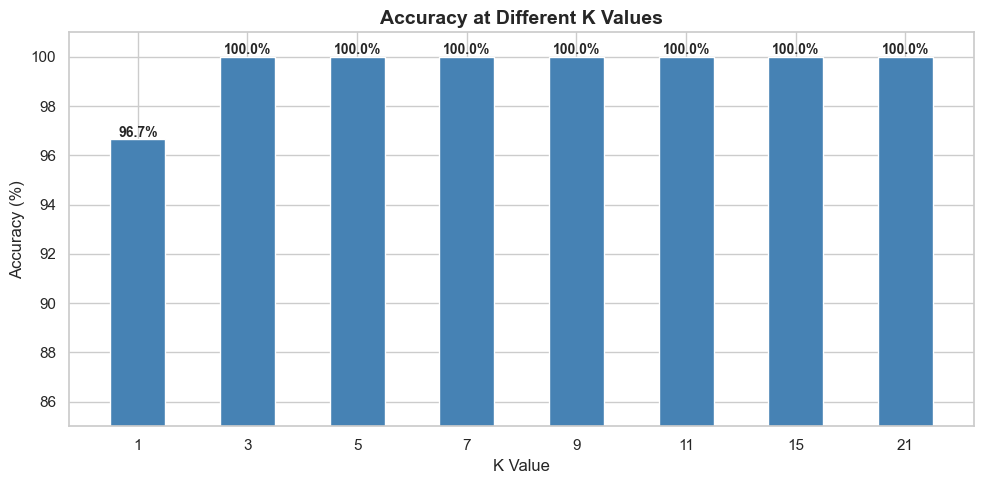

In [8]:
k_values  = [1, 3, 5, 7, 9, 11, 15, 21]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc*100)

plt.figure(figsize=(10, 5))
plt.bar([str(k) for k in k_values], accuracies,
        color='steelblue', edgecolor='white', width=0.5)
plt.title('Accuracy at Different K Values',
          fontsize=14, fontweight='bold')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(85, 101)
for i, v in enumerate(accuracies):
    plt.text(i, v+0.1, f'{v:.1f}%',
             ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()


INTERVIEW QUESTIONS — ANSWERS
══════════════════════════════════════════════════════

Q1. Why 'Lazy Learner'?
    KNN does NOT learn during training.
    It just memorizes the entire training data.
    All computation happens at prediction time.
    That is why it is called a Lazy Learner.

Q2. Choosing Optimal K?
    Too small K (K=1) = Overfitting (noisy)
    Too large K       = Underfitting (too smooth)
    Best way = Elbow Method
    Plot error rate vs K values
    Pick K where error rate stops decreasing fast.
    Usually odd number to avoid tie votes.

Q3. Impact of Scaling on KNN?
    KNN uses DISTANCE to find nearest neighbors.
    If features are not scaled:
    - Large value features dominate distance
    - Model gives wrong neighbors
    After StandardScaler:
    - All features have equal importance
    - Distance calculation is fair and accurate
    Scaling is MUST for KNN.

Q4. Common Distance Metrics?
    1. Euclidean Distance (default) 
       = Straight line distance between 2 points
    2. Manhattan Distance
       = Sum of absolute differences
    3. Minkowski Distance
       = Generalization of Euclidean & Manhattan
    4. Hamming Distance
       = Used for categorical data

══════════════════════════════════════════════════════
